# Hard Project 🟠 - Insurance Charges with a Pruned Decision Tree (log-target)

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. Justifying a **log1p target transform** with skew evidence from EDA.
2. Encoding a mixed numeric/categorical insurance table.
3. A proper 2-D hyper-parameter grid (`max_depth` × `min_samples_leaf`) under CV.
4. Translating log-scale predictions back to **dollars** and reporting $-metrics.
5. Spotting that the tree's first split is `smoker`.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # inline plotting inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → no IPython shell
    pass

import numpy as np                  # vector maths incl. log1p/expm1
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split, GridSearchCV       # split + grid search
from sklearn.tree import DecisionTreeRegressor                           # this chapter's model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean styling
plt.rcParams["figure.dpi"] = 100    # light crisp figures


### 1. Business question

> *A health insurer needs a transparent first-pass estimate of annual medical
> charges per customer for pricing triage. Regulators demand explainability,
> so a pruned tree (a handful of readable rules) is preferred over a black box.*

Dataset: 1,338 US insurance customers - age, sex, bmi, children, smoker,
region, and the target `charges` (annual medical cost in USD).

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Walk up to the course's '02_machine_learning' directory, then into 'data'.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # one level up per iteration
    return here / "data"

DATA_DIR = find_data_dir()          # canonical shared data folder

def load_insurance():
    # Read the local copy if it exists; otherwise download once and cache it.
    csv_path = DATA_DIR / "insurance.csv"
    if not csv_path.exists():       # first encounter fetches and saves
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

ins = load_insurance()
print(ins.shape)
ins.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### EDA part 1 - audit, target skew, the smoker fault-line

The money shot here is `charges`: extremely right-skewed because a small
segment of smokers generates enormous bills. That skew motivates modelling
`log1p(charges)` instead of raw dollars.

missing values: 0


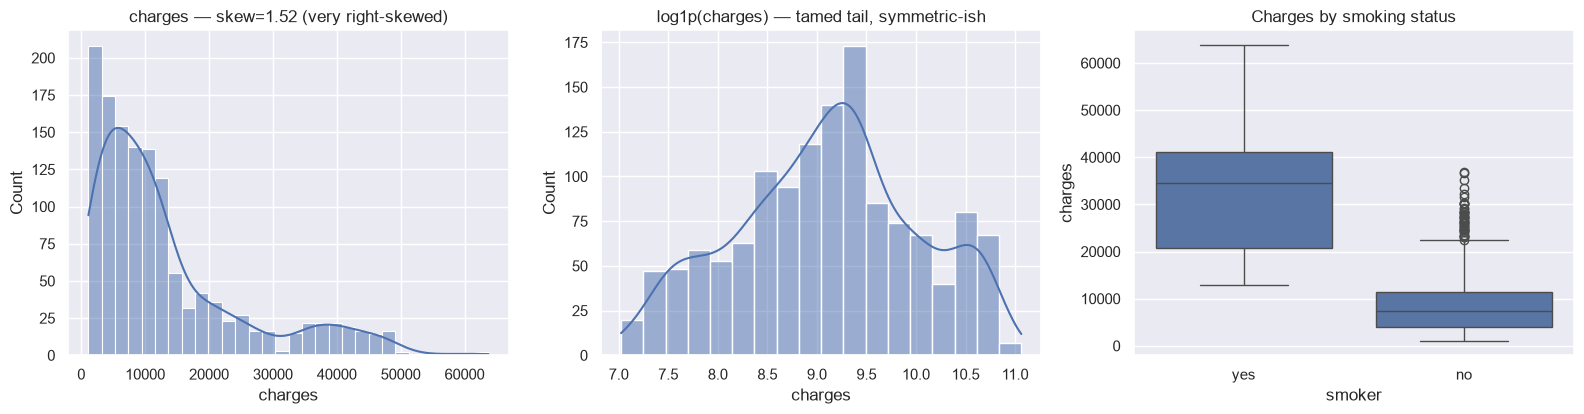

In [3]:
print("missing values:", ins.isna().sum().sum())   # null audit (expect 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
sns.histplot(ins["charges"], kde=True, ax=axes[0])               # RAW target: heavy right tail
axes[0].set_title(f"charges - skew={ins['charges'].skew():.2f} (very right-skewed)")
sns.histplot(np.log1p(ins["charges"]), kde=True, ax=axes[1])     # TRANSFORMED target: near-normal
axes[1].set_title("log1p(charges) - tamed tail, symmetric-ish")
sns.boxplot(data=ins, x="smoker", y="charges", ax=axes[2])       # the dominant categorical split
axes[2].set_title("Charges by smoking status")
plt.tight_layout(); plt.show()

### EDA part 2 - interaction preview + correlation panel

💡 Look at BMI vs charges coloured by smoking: two clouds with different
slopes. Charges explode only when high BMI *and* smoker co-occur - an
interaction a tree can carve out naturally with successive splits.

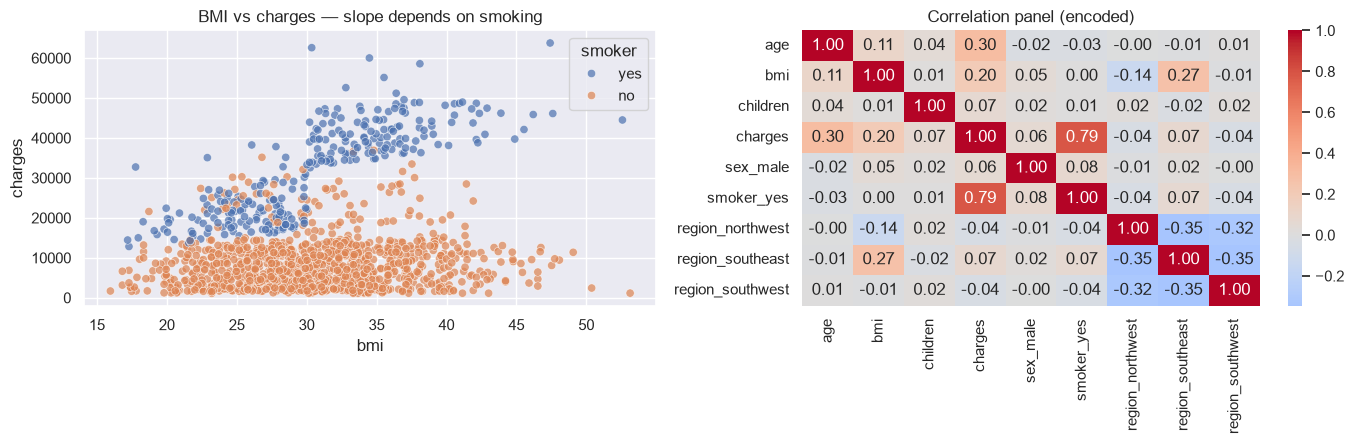

In [4]:
ins_enc_preview = pd.get_dummies(ins, columns=["sex", "smoker", "region"],
                                 drop_first=True)                # encode for correlation panel
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.scatterplot(data=ins, x="bmi", y="charges", hue="smoker",
                alpha=0.7, ax=axes[0])                          # visualise the interaction
axes[0].set_title("BMI vs charges - slope depends on smoking")
sns.heatmap(ins_enc_preview.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1])              # linear correlations, orientation only
axes[1].set_title("Correlation panel (encoded)")
plt.tight_layout(); plt.show()

### 2. Processing - encode dummies, log-transform target, split

- Dummies for sex/smoker/region (drop-first keeps k-1 levels).
- Target becomes `log1p(charges)`: relative errors matter in insurance, and
  the transform un-buries the signal from the tail.
- 20% test holdout, untouched until the final dollar-scale report.

In [5]:
df = pd.get_dummies(ins, columns=["sex", "smoker", "region"], drop_first=True)
features = [c for c in df.columns if c != "charges"]             # all predictors after encoding
X = df[features]
y_log = np.log1p(df["charges"])                                  # model log-dollars, not dollars

X_train, X_test, y_train_log, y_test_log, y_train_d, y_test_d = train_test_split(
    X, y_log, df["charges"],                                     # carry BOTH target views through
    test_size=0.2, random_state=42,
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (1070, 8) | test (268, 8)


### 3. Grid search: `max_depth` × `min_samples_leaf`

Two pruning dials at once: how many questions deep (depth) and how fat each
leaf must stay (min_samples_leaf). 5-fold CV on the training partition picks
the combination; scoring happens on the LOG scale where errors are comparable
across cheap and expensive customers.

In [6]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],      # None = grow freely, let min_samples_leaf brake
    "min_samples_leaf": [1, 5, 15, 30],    # fatter leaves → smoother steps, less memorisation
}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                                        # five-fold cross-validation
    scoring="neg_root_mean_squared_error",       # maximise -RMSE on log-charges
    n_jobs=-1,                                   # use all CPU cores for the audition
)
grid.fit(X_train, y_train_log)

best_tree = grid.best_estimator_                 # refit already done by GridSearchCV
print(f"best params : {grid.best_params_}")
print(f"CV log-RMSE : {-grid.best_score_:.4f}")

best params : {'max_depth': 5, 'min_samples_leaf': 15}
CV log-RMSE : 0.3909


### 4. Back to dollars + evaluation table

Predictions live in log space; `expm1` inverts them to dollars. ⚠️ Report
dollar metrics on the ORIGINAL scale - that's what the business feels - while
remembering RMSE there is dominated by expensive-customer misses.

In [7]:
def regression_report(y_true, y_pred, label):
    """Metrics row computed in raw dollars."""
    mae = mean_absolute_error(y_true, y_pred)                    # typical dollar miss
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))           # tail-sensitive dollar miss
    r2 = r2_score(y_true, y_pred)                                # variance explained
    print(f"{label:<26} MAE=${mae:>9,.0f}  RMSE=${rmse:>9,.0f}  R²={r2:6.3f}")
    return {"model": label, "MAE_$": mae, "RMSE_$": rmse, "R2": r2}

pred_test_d = np.expm1(best_tree.predict(X_test))                # invert the log transform

results = [
    regression_report(y_test_d, np.full(len(y_test_d), y_train_d.mean()),
                      "baseline (mean charges)"),
    regression_report(y_test_d, pred_test_d, f"tree {grid.best_params_}"),
]
pd.DataFrame(results)

baseline (mean charges)    MAE=$    9,593  RMSE=$   12,466  R²=-0.001
tree {'max_depth': 5, 'min_samples_leaf': 15} MAE=$    2,200  RMSE=$    4,478  R²= 0.871


,model,MAE_$,RMSE_$,R2
0,baseline (mean charges),9593.338461,12465.610442,-0.000919
1,"tree {'max_depth': 5, 'min_samples_leaf': 15}",2199.570291,4478.418587,0.870812


### What did the model learn? Root split + importances

The very first question the tree asks is stored at `tree_.feature[0]`.
Expect `smoker_yes` - the single most charge-defining fact about a customer.

root node splits on: smoker_yes


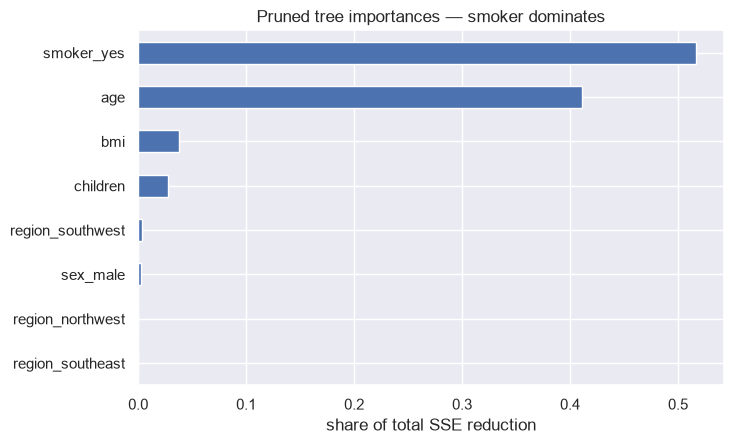

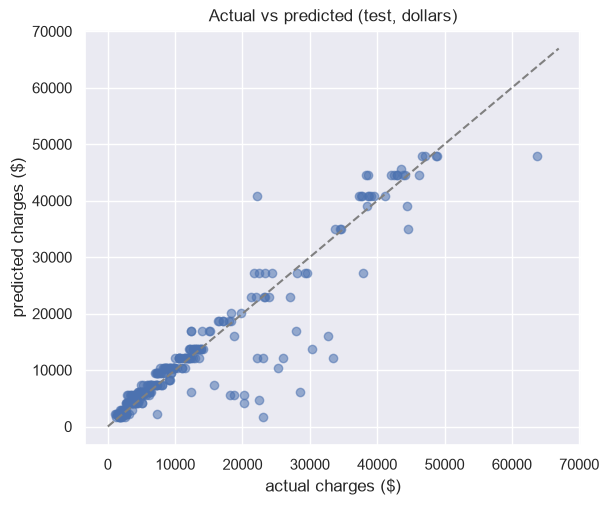

In [8]:
root_feature = features[best_tree.tree_.feature[0]]              # index 0 IS the root node
print(f"root node splits on: {root_feature}")

imp = pd.Series(best_tree.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.6))
imp.plot.barh(ax=ax)                                             # importance leaderboard
ax.set_title("Pruned tree importances - smoker dominates")
ax.set_xlabel("share of total SSE reduction")
plt.tight_layout(); plt.show()

# Actual-vs-predicted in dollars: the diagonal is perfection; note under-
# prediction of the extreme tail (log training makes big bills weigh less).
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(y_test_d, pred_test_d, alpha=0.55)
lims = [0, max(y_test_d.max(), pred_test_d.max()) * 1.05]
ax.plot(lims, lims, ls="--", c="gray")                           # y=x reference line
ax.set(xlabel="actual charges ($)", ylabel="predicted charges ($)",
       title="Actual vs predicted (test, dollars)")
plt.show()

### Findings

1. **Smoker splits first.** The root question is `smoker_yes`, confirming the
   boxplot: smoking status is the largest single driver of charges.
2. **The log transform was justified, not decorative:** raw skew ≈ 1.5+
   collapses to near-symmetric after `log1p`, and CV behaves far better on
   the transformed scale.
3. **Grid search lands on a shallow-ish tree** (modest depth + non-trivial
   leaf size): enough capacity for the smoker×BMI interaction, not enough to
   memorise 1,000+ customers.
4. **Dollar metrics:** MAE typically ~\$2.5-3k versus ~\$9k for the naive mean
   baseline; R² around ~0.75-0.85 depending on the draw - strong for one tree.
5. **BMI matters mostly ABOVE the smoker cut** - the tree captures the
   interaction via nested splits rather than a product term.

### Limitations

- Optimising log-space RMSE ≠ optimising dollar MAE; a direct-dollar objective
  or quantile trees would serve pricing better.
- Tail under-prediction: the costliest customers are systematically missed -
  exactly the cases insurers fear (see actual-vs-pred droop at high values).
- US-only, year-unknown data; charges reflect one market's pricing regime.